<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Random Forest Regression 
</p>

In [11]:
# Imports - core utils, data wrangling, ML, optimization, and plotting

# Standard library
import os
import pickle
import time
import warnings

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# ML and evaluation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
)
from sklearn.model_selection import learning_curve

# Bayesian optimization
from skopt import BayesSearchCV
from skopt.space import Integer, Real

# Suppress known compatibility/noise warnings
warnings.filterwarnings("ignore", category=UserWarning, module="skopt")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Dataset: Load Splits 
</p>

In [12]:
# Paths - aligned with the MLR, LightGBM, and XGBoost notebooks
TRAIN_CSV = "Data_Files/train.csv"
TEST_CSV  = "Data_Files/test.csv"
FOLDS_NPY = "Data_Files/train_folds.npy"
CV_SPLITS_NPZ = "Data_Files/train_time_series_cv_splits.npz"

MODELS_DIR     = "Models"
FIGURES_DIR    = "Figures"
CV_RESULTS_DIR = "CV_Results"
RESIDUALS_DIR  = "Residuals"

for directory in [MODELS_DIR, FIGURES_DIR, CV_RESULTS_DIR, RESIDUALS_DIR]:
    os.makedirs(directory, exist_ok=True)

CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "rf_bayes_cv_results.csv")
MODEL_PATH      = os.path.join(MODELS_DIR, "rf_final_model.pkl")

# Load time-aware train/test split and predefined train folds
_df_train = pd.read_csv(TRAIN_CSV)
_df_test  = pd.read_csv(TEST_CSV)
_fold_assignments = np.load(FOLDS_NPY)

cv_npz = np.load(CV_SPLITS_NPZ)
n_splits = int(cv_npz["n_splits"])
cv_splits = [
    (cv_npz[f"fold_{i}_train_idx"], cv_npz[f"fold_{i}_val_idx"])
    for i in range(n_splits)
]


df_train = _df_train.copy()
df_test = _df_test.copy()
fold_assignments = _fold_assignments.copy()

# Optional datetime parsing for reporting/saving
for df in [df_train, df_test]:
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Feature/target setup
feature_names = [
    "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature", "snr"
]
target_col = "PL"

required_cols = [target_col, "device_id", *feature_names]
missing_train = [c for c in required_cols if c not in df_train.columns]
missing_test  = [c for c in required_cols if c not in df_test.columns]

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns | train: {missing_train} | test: {missing_test}"
    )

if len(fold_assignments) != len(df_train):
    raise ValueError(
        f"fold_assignments length ({len(fold_assignments)}) does not match "
        f"df_train length ({len(df_train)})"
    )


def validate_cv_splits(cv_splits, fold_assignments, name="cv_splits"):
    fold_ids = sorted(np.unique(fold_assignments[fold_assignments >= 0]).astype(int).tolist())
    if len(cv_splits) != len(fold_ids):
        raise ValueError(f"{name} has {len(cv_splits)} splits but fold metadata has {len(fold_ids)} validation folds.")

    for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):
        tr_idx = np.asarray(tr_idx, dtype=int)
        val_idx = np.asarray(val_idx, dtype=int)
        if tr_idx.size == 0 or val_idx.size == 0:
            raise ValueError(f"{name} fold {fold_num} has an empty train or validation index set.")
        if np.intersect1d(tr_idx, val_idx).size:
            raise ValueError(f"{name} fold {fold_num} has train/validation overlap.")
        if tr_idx.max() >= val_idx.min():
            raise ValueError(f"{name} fold {fold_num} trains on rows at or after its validation window.")

        expected_val_idx = np.flatnonzero(fold_assignments == fold_num)
        if not np.array_equal(val_idx, expected_val_idx):
            raise ValueError(f"{name} fold {fold_num} validation indices do not match train_folds.npy metadata.")


validate_cv_splits(cv_splits, fold_assignments)

# Train/test matrices
X_train_df = df_train[feature_names].copy()
X_test_df  = df_test[feature_names].copy()

X_train = X_train_df.to_numpy()
y_train = df_train[target_col].astype(float).to_numpy()

X_test = X_test_df.to_numpy()
y_test = df_test[target_col].astype(float).to_numpy()

print(f"Training samples: {len(df_train)}, Test samples: {len(df_test)}")
if "time" in df_train.columns and "time" in df_test.columns:
    print(f"Train window: {df_train.time.min()} -> {df_train.time.max()}")
    print(f"Test window:  {df_test.time.min()} -> {df_test.time.max()}")

unique, counts = np.unique(fold_assignments, return_counts=True)
print("Fold sizes:", dict(zip(unique.astype(int), counts.astype(int))))


Training samples: 1663627, Test samples: 415907
Train window: 2024-10-01 00:01:07.420593+00:00 -> 2025-08-12 17:18:53.293125+00:00
Test window:  2025-08-12 17:19:02.126782+00:00 -> 2025-09-30 23:59:55.971870+00:00
Fold sizes: {np.int64(0): np.int64(554543), np.int64(1): np.int64(277271), np.int64(2): np.int64(277271), np.int64(3): np.int64(277271), np.int64(4): np.int64(277271)}


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
RF Model And Search Setup
</p>

In [14]:
# RF model helper
def create_rf_model(oob_score=False, n_jobs=1):
    return RandomForestRegressor(
        criterion="squared_error",
        bootstrap=True,
        oob_score=oob_score,
        random_state=42,
        n_jobs=n_jobs,
    )

# RF model used inside Bayesian CV
rf = create_rf_model(oob_score=False, n_jobs=1)


# param space for Bayesian optimization
search_spaces = {
    "n_estimators": Integer(300, 800),
    "max_features": Real(0.3, 0.8, prior="uniform"),
    "max_depth": Integer(1, 10),
    "min_samples_split": Integer(10, 80),
    "min_samples_leaf": Integer(5, 40),
    "max_samples": Real(0.7, 1.0, prior="uniform"),
}

# Setup scoring
scoring = {"neg_root_mean_squared_error": "neg_root_mean_squared_error", "r2": "r2",}


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
 Bayesian Optimization
</p>

In [15]:
#Bayesian optimization
bayes_cv = BayesSearchCV(
    estimator=rf,
    search_spaces=search_spaces,
    n_iter=60,
    scoring=scoring,
    refit="neg_root_mean_squared_error",
    cv=cv_splits,
    n_jobs=8,
    n_points=2,
    random_state=42,
    verbose=1,
    return_train_score=True,
    error_score="raise",
    optimizer_kwargs={
        "base_estimator": "GP",
        "n_initial_points": 15,
        "acq_func": "gp_hedge",
    },
)

print(
    f"Starting Bayesian optimization with {bayes_cv.n_iter} iterations "
    f"and {len(cv_splits)}-fold cross-validation per candidate...\n"
)

# Fit Bayesian optimizer on training data
t0 = time.time()
bayes_cv.fit(X_train_df, y_train)
t1 = time.time()

print(f"\nBayesian optimization complete in {(t1 - t0) / 60:.2f} minutes.")

print("\nExtracting results...")

# Pull all tried configs/results into a dataframe
bayes_results = pd.DataFrame(bayes_cv.cv_results_)
print(f"\nTried {bayes_results.shape[0]} configurations.")

print("\nBest Parameters Found:")
print(bayes_cv.best_params_)
print(f"Best CV RMSE: {-bayes_cv.best_score_:.4f}")

# Save full CV results
bayes_results.to_csv(CV_RESULTS_PATH, index=False)
print(f"\nSaved BayesSearchCV cv_results_ to: {CV_RESULTS_PATH}")


Starting Bayesian optimization with 60 iterations and 5-fold cross-validation per candidate...

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitt

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Summarize best CV results for each max_depth
</p>

In [16]:
# Load saved CV-search results and derive the best parameters robustly
legacy_cv_result_paths = [
    os.path.join("RFs", "Results", "rf_bayes_cv_results.csv"),
    os.path.join("Results", "rf_bayes_cv_results.csv"),
]

if os.path.exists(CV_RESULTS_PATH):
    bayes_results = pd.read_csv(CV_RESULTS_PATH)
else:
    bayes_results = None
    for legacy_path in legacy_cv_result_paths:
        if os.path.exists(legacy_path):
            bayes_results = pd.read_csv(legacy_path)
            bayes_results.to_csv(CV_RESULTS_PATH, index=False)
            print(f"Migrated legacy CV results to: {CV_RESULTS_PATH}")
            break

    if bayes_results is None:
        raise FileNotFoundError(
            f"No CV results found. Run the BayesSearchCV cell or provide {CV_RESULTS_PATH}."
        )

if bayes_results.empty:
    raise ValueError("Loaded CV results are empty.")

required_cv_cols = [
    "mean_test_neg_root_mean_squared_error",
    "std_test_neg_root_mean_squared_error",
    "mean_test_r2",
    "std_test_r2",
    "param_max_depth",
]
missing_cv_cols = [c for c in required_cv_cols if c not in bayes_results.columns]
if missing_cv_cols:
    raise KeyError(f"Missing expected CV result columns: {missing_cv_cols}")

# Best overall configuration by validation RMSE
best_idx = bayes_results["mean_test_neg_root_mean_squared_error"].idxmax()
best_row = bayes_results.loc[best_idx]

param_cols = [c for c in bayes_results.columns if c.startswith("param_")]
int_params = {"n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"}

best_params = {}
for col in param_cols:
    name = col.replace("param_", "")
    value = best_row[col]
    if pd.isna(value):
        continue

    try:
        numeric_value = float(value)
    except (TypeError, ValueError):
        numeric_value = value

    if name in int_params:
        value = int(round(float(numeric_value)))
    elif isinstance(numeric_value, (int, float, np.integer, np.floating)):
        value = float(numeric_value)
    else:
        value = numeric_value

    best_params[name] = value

best_cv_rmse = -float(best_row["mean_test_neg_root_mean_squared_error"])
best_cv_r2 = float(best_row["mean_test_r2"])

print("Best Parameters Found:", best_params)
print(f"Best CV RMSE: {best_cv_rmse:.4f}")
print(f"Best CV R2:   {best_cv_r2:.4f}")

# Best-per-depth summary for plotting
bayes_results["param_max_depth"] = pd.to_numeric(bayes_results["param_max_depth"], errors="coerce")
plot_param_cols = [c.split("param_")[1] for c in bayes_results.columns if c.startswith("param_")]

rows = []
for depth in sorted(bayes_results["param_max_depth"].dropna().unique()):
    df_depth = bayes_results[bayes_results["param_max_depth"] == depth]
    idx = df_depth["mean_test_neg_root_mean_squared_error"].idxmax()
    row = df_depth.loc[idx]

    summary_row = {
        "max_depth": depth,
        "best_cv_rmse": -row["mean_test_neg_root_mean_squared_error"],
        "std_cv_rmse": row["std_test_neg_root_mean_squared_error"],
        "best_cv_r2": row["mean_test_r2"],
        "std_cv_r2": row["std_test_r2"],
    }

    for param in plot_param_cols:
        summary_row[param] = row[f"param_{param}"]

    rows.append(summary_row)

cv_df = pd.DataFrame(rows).sort_values("max_depth")

tbl = cv_df.copy()
num_cols = tbl.select_dtypes(include="number").columns
tbl[num_cols] = tbl[num_cols].round(4)

tbl_t = tbl.set_index("max_depth").T
tbl_t.index.name = "metric/param"
tbl_t.columns = [f"max_depth={int(c)}" for c in tbl_t.columns]
display(tbl_t)

Best Parameters Found: {'max_depth': 6, 'max_features': 0.5544395791363066, 'max_samples': 0.7, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 300}
Best CV RMSE: 5.8127
Best CV R2:   0.9029


,max_depth=1,max_depth=2,max_depth=3,max_depth=4,max_depth=5,max_depth=6,max_depth=7,max_depth=8,max_depth=9,max_depth=10
metric/param,,,,,,,,,,
best_cv_rmse,12.2454,8.0396,6.0407,5.8757,5.8705,5.8127,5.8159,5.8404,5.8226,5.8195
std_cv_rmse,0.7318,0.5843,0.5934,0.6442,0.5515,0.4958,0.4499,0.4637,0.4267,0.4098
best_cv_r2,0.5722,0.8157,0.8949,0.9004,0.9009,0.9029,0.9027,0.9020,0.9026,0.9027
std_cv_r2,0.0487,0.0220,0.0225,0.0231,0.0200,0.0191,0.0185,0.0184,0.0177,0.0176
max_features,0.7977,0.6758,0.7996,0.8000,0.5674,0.5544,0.5110,0.3000,0.3000,0.3536
max_samples,0.8937,0.8672,0.7651,1.0000,0.9356,0.7000,0.9202,0.8251,1.0000,0.7000
min_samples_leaf,9.0000,39.0000,35.0000,40.0000,25.0000,5.0000,27.0000,40.0000,5.0000,5.0000
min_samples_split,22.0000,59.0000,44.0000,80.0000,51.0000,10.0000,75.0000,80.0000,80.0000,80.0000
n_estimators,437.0000,491.0000,506.0000,300.0000,582.0000,300.0000,629.0000,638.0000,597.0000,790.0000


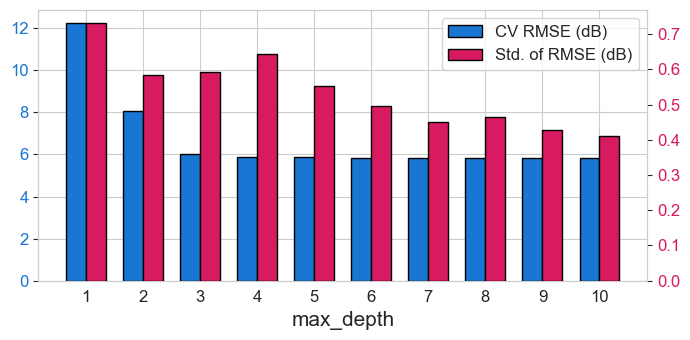

In [17]:
# Display RF CV RMSE and RMSE variability across all searched max_depth values

tick_fontsize = 12
axis_labelsize = 15
legend_fontsize = 12

sns.set_style("whitegrid")

cv_df_all = cv_df.copy().sort_values("max_depth").reset_index(drop=True)
x = np.arange(len(cv_df_all["max_depth"]))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_df_all["best_cv_rmse"],
    bar_width,
    color="#1976d2",
    label="RMSE",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
ax1.set_xlabel("max_depth", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(v)}" for v in cv_df_all["max_depth"]], fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor="#1976d2", labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_df_all["std_cv_rmse"],
    bar_width,
    color="#d81b60",
    label="Std. of RMSE",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
ax2.tick_params(axis="y", labelcolor="#d81b60", labelsize=tick_fontsize)
ax2.grid(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#1976d2", edgecolor="black", label="CV RMSE (dB)"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#d81b60", edgecolor="black", label="Std. of RMSE (dB)"),
]
ax1.legend(handles=handles, loc="upper right", fontsize=legend_fontsize)

fig.tight_layout()
plt.show()

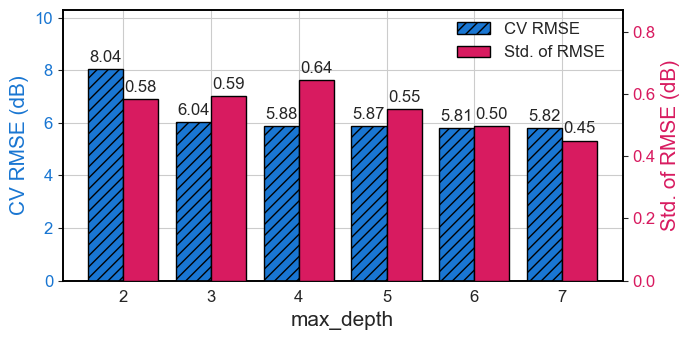

Saved figure: Figures\RF_bestRMSE_STD_perDepth.png


In [23]:
# Plot and save the focused RF CV RMSE figure based on the max_depth

tick_fontsize   = 12
axis_labelsize  = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

cv_df_plot = cv_df.copy()
cv_df_plot["max_depth"] = pd.to_numeric(cv_df_plot["max_depth"], errors="coerce")
cv_df_plot = cv_df_plot[(cv_df_plot["max_depth"] >= 2) & (cv_df_plot["max_depth"] < 8)].copy()
cv_df_plot = cv_df_plot.sort_values("max_depth").reset_index(drop=True)

if cv_df_plot.empty:
    raise ValueError("No RF CV rows found for max_depth between 2 and 8.")

x = np.arange(len(cv_df_plot["max_depth"]))
bar_width = 0.40

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(x - bar_width / 2, cv_df_plot["best_cv_rmse"], bar_width, color="#1976d2", edgecolor="black", linewidth=1, zorder=3)
for bar in bars1:
    bar.set_hatch("///")

ax1.set_xlabel("max_depth", fontsize=axis_labelsize)
ax1.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize, color="#1976d2")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(v)}" for v in cv_df_plot["max_depth"]], fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor="#1976d2", labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width / 2, cv_df_plot["std_cv_rmse"], bar_width, color="#d81b60", edgecolor="black", linewidth=1, zorder=3)
ax2.set_ylabel("Std. of RMSE (dB)", fontsize=axis_labelsize, color="#d81b60")
ax2.tick_params(axis="y", labelcolor="#d81b60", labelsize=tick_fontsize)
ax2.grid(False)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

ax1.bar_label(bars1, fmt="%.2f", padding=3, fontsize=tick_fontsize)
ax2.bar_label(bars2, fmt="%.2f", padding=3, fontsize=tick_fontsize)

ax1.set_ylim(0, float(cv_df_plot["best_cv_rmse"].max()) * 1.28)
ax2.set_ylim(0, float(cv_df_plot["std_cv_rmse"].max()) * 1.35)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#1976d2", edgecolor="black", hatch="///", label="CV RMSE"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#d81b60", edgecolor="black", label="Std. of RMSE"),
]
leg = ax1.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.98, 0.98), borderaxespad=0.0, fontsize=legend_fontsize, frameon=False)

fig.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "RF_bestRMSE_STD_perDepth.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.show()
print(f"Saved figure: {fig_path}")

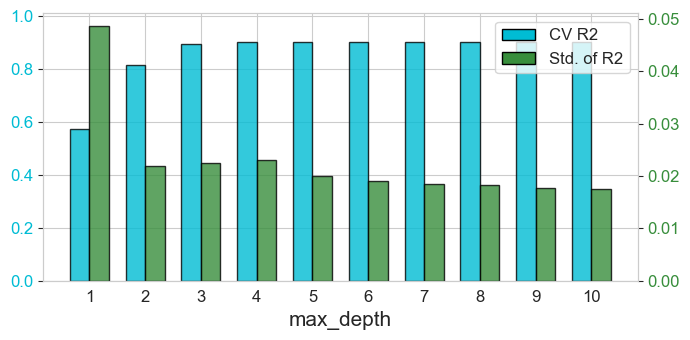

In [19]:
# Display RF CV R2 and R2 variability across searched max_depth values

tick_fontsize = 12
axis_labelsize = 15
legend_fontsize = 12

sns.set_style("whitegrid")

cv_df_all = cv_df.copy().sort_values("max_depth").reset_index(drop=True)
x = np.arange(len(cv_df_all["max_depth"]))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_df_all["best_cv_r2"],
    bar_width,
    color="#00bcd4",
    edgecolor="black",
    linewidth=1,
    alpha=0.8,
    label="R2",
)
ax1.set_xlabel("max_depth", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(v)}" for v in cv_df_all["max_depth"]], fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor="#00bcd4", labelsize=tick_fontsize)
ax1.tick_params(axis="x", labelsize=tick_fontsize)
ax1.set_ylim(0, 1.01)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_df_all["std_cv_r2"],
    bar_width,
    color="#388e3c",
    edgecolor="black",
    linewidth=1,
    alpha=0.8,
    label="Std. of R2",
)
ax2.tick_params(axis="y", labelcolor="#388e3c", labelsize=tick_fontsize)
ax2.grid(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#00bcd4", edgecolor="black", label="CV R2"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#388e3c", edgecolor="black", label="Std. of R2"),
]
ax1.legend(handles=handles, loc="upper right", fontsize=legend_fontsize)

fig.tight_layout()
plt.show()

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
 Train on All Training Data and Test Evaluation 
</p>

In [20]:
# Train final model, evaluate on held-out test, and save model/residual artifacts

final_params = best_params.copy()
final_params.pop("bootstrap", None)  # only needed if bootstrap was included in search_spaces

best_model = create_rf_model(oob_score=True, n_jobs=-1)
best_model.set_params(**final_params)
best_model.fit(X_train_df, y_train)

print("Best Parameters Used:", best_params)
print("\nFinal Random Forest model trained on the full training split.")

# Train/test predictions
y_train_pred = best_model.predict(X_train_df)
y_test_pred = best_model.predict(X_test_df)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_median_ae = median_absolute_error(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    "Metric": [
        "Train MSE", "Train RMSE", "Train R2",
        "Test MSE", "Test RMSE", "Test R2",
        "Test MAPE (%)", "Test Median AE",
    ],
    "Value": [
        train_mse, train_rmse, train_r2,
        test_mse, test_rmse, test_r2,
        test_mape * 100, test_median_ae,
    ],
})

print("\nModel Evaluation Metrics:")
display(metrics_df)

# Save final model
with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_model, f)
print(f"\nTrained Random Forest model saved to: {MODEL_PATH}")

# TEST residuals
PL_pred_test = y_test_pred
resid_test = y_test - PL_pred_test

rf_test_df = pd.DataFrame({
    "model":       "RF",
    "split":       "test",
    "row_id":      np.arange(len(df_test), dtype=int),
    "time":        df_test.get("time", pd.Series(index=df_test.index, dtype=float)).values,
    "device_id":   df_test["device_id"].values,
    "distance":    df_test["distance"].values,
    "frequency":   df_test["frequency"].values,
    "c_walls":     df_test["c_walls"].values,
    "w_walls":     df_test["w_walls"].values,
    "co2":         df_test["co2"].values,
    "humidity":    df_test["humidity"].values,
    "pm25":        df_test["pm25"].values,
    "pressure":    df_test["pressure"].values,
    "temperature": df_test["temperature"].values,
    "snr":         df_test["snr"].values,
    "PL_true":     y_test,
    "PL_pred":     PL_pred_test,
    "resid_db":    resid_test,
})

test_residual_path = os.path.join(RESIDUALS_DIR, "residuals_RF_test.csv")
rf_test_df.to_csv(test_residual_path, index=False)
print(f"[TEST] Saved Random Forest test residuals: {test_residual_path}")

# OOF residuals using the selected best parameters
y_pred_oof = np.full(len(y_train), np.nan, dtype=float)
if not cv_splits:
    raise ValueError("No validation splits found for OOF residual generation.")

for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):

    fold_model = create_rf_model(oob_score=False, n_jobs=1)
    fold_model.set_params(**final_params)
    fold_model.fit(X_train_df.iloc[tr_idx], y_train[tr_idx])
    y_pred_oof[val_idx] = fold_model.predict(X_train_df.iloc[val_idx])

mask = ~np.isnan(y_pred_oof)
PL_pred_oof = y_pred_oof[mask]
resid_oof = y_train[mask] - PL_pred_oof

if mask.sum() != len(y_train):
    print(f"OOF residuals generated for {mask.sum()} of {len(y_train)} training rows.")

rf_oof_df = pd.DataFrame({
    "model":       "RF",
    "split":       "oof",
    "row_id":      np.arange(len(df_train), dtype=int)[mask],
    "fold":        fold_assignments.astype(int)[mask],
    "time":        df_train.get("time", pd.Series(index=df_train.index, dtype=float)).values[mask],
    "device_id":   df_train["device_id"].values[mask],
    "distance":    df_train["distance"].values[mask],
    "frequency":   df_train["frequency"].values[mask],
    "c_walls":     df_train["c_walls"].values[mask],
    "w_walls":     df_train["w_walls"].values[mask],
    "co2":         df_train["co2"].values[mask],
    "humidity":    df_train["humidity"].values[mask],
    "pm25":        df_train["pm25"].values[mask],
    "pressure":    df_train["pressure"].values[mask],
    "temperature": df_train["temperature"].values[mask],
    "snr":         df_train["snr"].values[mask],
    "PL_true":     y_train[mask],
    "PL_pred":     PL_pred_oof,
    "resid_db":    resid_oof,
})

oof_residual_path = os.path.join(RESIDUALS_DIR, "residuals_RF_oof.csv")
rf_oof_df.to_csv(oof_residual_path, index=False)
print(f"[OOF] Saved Random Forest OOF residuals: {oof_residual_path}")


Best Parameters Used: {'max_depth': 6, 'max_features': 0.5544395791363066, 'max_samples': 0.7, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 300}

Final Random Forest model trained on the full training split.

Model Evaluation Metrics:


,Metric,Value
0,Train MSE,26.121795
1,Train RMSE,5.110949
2,Train R2,0.926216
3,Test MSE,27.179096
4,Test RMSE,5.213357
5,Test R2,0.923333
6,Test MAPE (%),4.473142
7,Test Median AE,3.091338



Trained Random Forest model saved to: Models\rf_final_model.pkl
[TEST] Saved Random Forest test residuals: Residuals\residuals_RF_test.csv
[OOF] Saved Random Forest OOF residuals: Residuals\residuals_RF_oof.csv


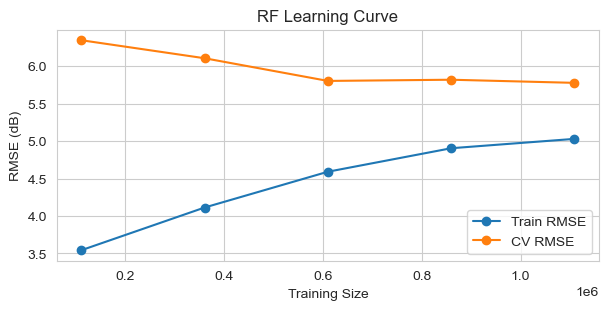

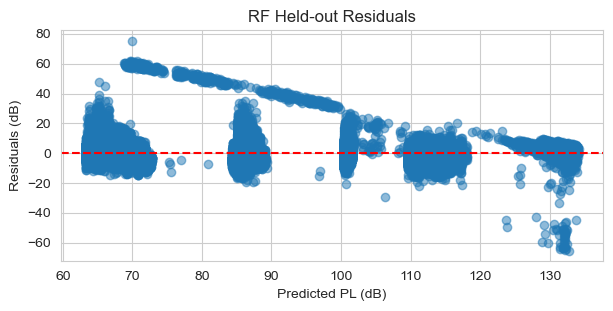

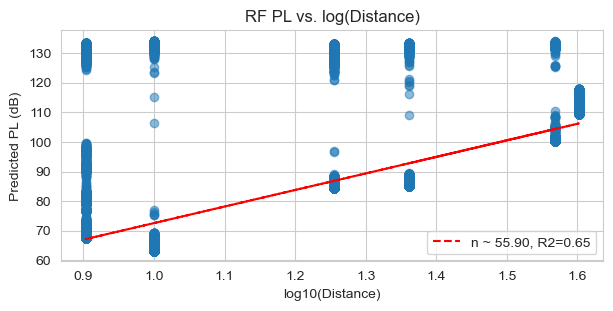

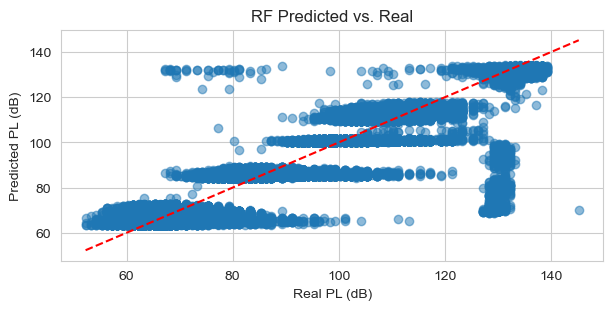

In [21]:
# Random Forest diagnostic plots

rf_model = best_model
figsize = (7, 3)

# 1. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_model,
    X_train_df,
    y_train,
    cv=cv_splits,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="neg_root_mean_squared_error",
)
train_rmse_curve = -train_scores.mean(axis=1)
val_rmse_curve = -test_scores.mean(axis=1)

plt.figure(figsize=figsize)
plt.plot(train_sizes, train_rmse_curve, "o-", label="Train RMSE")
plt.plot(train_sizes, val_rmse_curve, "o-", label="CV RMSE")
plt.xlabel("Training Size")
plt.ylabel("RMSE (dB)")
plt.title("RF Learning Curve")
plt.legend()
plt.show()

# 2. Held-out residuals
plt.figure(figsize=figsize)
plt.scatter(y_test_pred, resid_test, alpha=0.5)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predicted PL (dB)")
plt.ylabel("Residuals (dB)")
plt.title("RF Held-out Residuals")
plt.show()

# 3. Physics consistency: PL vs. log(distance)
dist = df_test["distance"].to_numpy()
log_dist = np.log10(dist + 1e-6)
slope, intercept, r_value, _, _ = linregress(log_dist, y_test_pred)

plt.figure(figsize=figsize)
plt.scatter(log_dist, y_test_pred, alpha=0.5)
plt.plot(log_dist, intercept + slope * log_dist, "r--", label=f"n ~ {slope:.2f}, R2={r_value**2:.2f}")
plt.xlabel("log10(Distance)")
plt.ylabel("Predicted PL (dB)")
plt.title("RF PL vs. log(Distance)")
plt.legend()
plt.show()

# 4. Predicted vs. real PL
plt.figure(figsize=figsize)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Real PL (dB)")
plt.ylabel("Predicted PL (dB)")
plt.title("RF Predicted vs. Real")
plt.show()
